In [1]:
import numpy as np
import timeit
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from numpy.linalg import eig
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
np.random.seed(1)

In [3]:
np.set_printoptions(precision=6, suppress=True)
torch.set_printoptions(precision=6)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Times New Roman'

### **Global constants ($n$, $t_0$, $t_p$, $t_{final}$, $\gamma$, $p_{d_i}$)**

In [4]:
# n followers
n = 4

# time
t0 = 0.00
tp = 0.14531249999999998
tf = 0.20

h = 0.001 # time step length
num_steps = round((tf-t0)/h)
# torch.autograd.set_detect_anomaly(True)

# Caputo fractional order
q = 0.776171875

In [5]:
# desired displacement between the i-th follower and the leader
# example: pdi = [[-2,2], [-2,-2], [2,-2], [2,2]]


# pdi = {1:-0.1, 2:0.1, 3:-0.1, 4:-0.1, 5:0.1, 6:-0.1, 7:0.1, 8:0.1}
# pdi = {1:-0.5, 2:0.5, 3:-0.5, 4:-0.5, 5:0.5, 6:-0.5, 7:0.5, 8:0.5}

pdi = {1:-2, 2:2, 3:-2, 4:-2, 5:2, 6:-2, 7:2, 8:2}

### **More global constants ($\alpha$, $\beta$, $c$, $b$, $\kappa$, $k_1$, $k_2$, $k_3$)**

In [6]:
# constant for virtual leader dynamics
alpha = -2.26171875
beta = -2.68359375

c = 8.349609375
b = 2.271484375
d = 1 # pinning mechananism indicator (i.e. 1: connection exists; 0: no connection between the agent and the leader)

kappa = 0.47251953125

# building the matrix C, positive gains
k1 = 1.9609375
k2 = 8.662109375
k3 = 0.3105806640625004 

In [7]:
# order 4 graph (according to Figure 1(b), directed blue arrows)
Vertex = {'1x', '1y', '2x', '2y', '3x', '3y', '4x', '4y'}

# adjacency matrix A_adj, 1->2, 2->3, 3->4, 4->1
A_adj = [[0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 0, 0, 0, 1],
         [1, 0, 0, 0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0, 0, 0, 0]]

# initialize D_dia to be a zero matrix
D_dia = [[0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0]]

# D_dia is a diagonal matrix with l_ii = ( Σ(i≠j) a_ij )
for i in range(len(A_adj)):
    D_dia[i][i] = sum(A_adj[i][j] for j in range(len(A_adj)) if i!=j)

# # D_dia is a diagonal matrix with l_ij = −a_ij, for ∀i≠j
for i in range(len(A_adj)):
    for j in range(len(A_adj)):
        if i!=j:
            D_dia[i][j] = -A_adj[i][j]

In [8]:
# Laplacian matrix of the system
L = np.array(D_dia) - np.array(A_adj)

In [9]:
# A_bar
A = [0,0,1,0,0,0,0,1,alpha,0,beta,0,0,alpha,0,beta]
A = np.array(A).reshape(4,4)

I = np.eye(4)

A_bar = np.kron(A,I).reshape(16,16)

In [10]:
ones = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
ones = np.array(ones).reshape(16,1)

# X_bar = np.kron(X, ones).reshape(16,16)
# X_bar_T = np.transpose(X_bar)

In [11]:
# PSI (C_bar)

upper_left = -(k2*c)*np.eye(8) # the upper left part of the matric C_bar
upper_right = np.zeros(64).reshape(8,8) # the lower right part of the matrix C_bar

C_upper = np.hstack((upper_left, upper_right))

lower_left = -(k2*c*d)*np.eye(8) - k1*L # the lower left part of the matric C_bar
lower_right = -(k2*c*d)*np.eye(8) - k1*L # the lower right part of the matrix C_bar

C_lower = np.hstack((lower_left, lower_right))

C_bar = np.vstack((C_upper, C_lower))
# C_bar.shape

In [12]:
# set for every PV value at different time points, for plotting and also for calculating Pc
P = {'p0x':[], 'p0y':[], 'p1x':[], 'p1y':[], 'p2x':[], 'p2y':[], 'p3x':[], 'p3y':[], 'p4x':[], 'p4y':[]}
V = {'v0x':[], 'v0y':[], 'v1x':[], 'v1y':[], 'v2x':[], 'v2y':[], 'v3x':[], 'v3y':[], 'v4x':[], 'v4y':[]}

### **Initial states (pre-input datasets for calculating $\bar{ξ}$)**
#### $p_0, \, v_0, \, p_1, \, v_1, \, p_2, \, v_2, \, p_3, \, v_3, \, p_4, \, v_4$

In [13]:
# number of followers
n = 4

# number of input points, i.e. length of p0 = 50
input_size = 1

In [14]:
# set p0 manually, create pi(p1, p2, ..., pn) randomly
def create_p(size):
    p = []
    for s in range(size):
        p_elem = np.random.uniform(0,15)
        p.append(round(p_elem,3))
    return p

p0 = np.array([[7.5], [7.5]])
pi = []

# follow the topological structure of multi-UAV systems described in figure 1??

for i in range(n):
    pi.append(np.array([create_p(input_size), create_p(input_size)]))

In [15]:
# create v0, vi(v1, v2, ..., vn)
def create_v(size): # D^gamma_t p0(t) = v0(t)? constraint?
    v = []
    for s in range(size):
        v_elem = np.random.uniform(-5,5)
        v.append(round(v_elem,3))
    return v

v0 = np.array([[2.5], [2.5]])
vi = []

for i in range(n):
    vi.append(np.array([create_v(input_size), create_v(input_size)]))

#### **Pre-input dataset: input_pv** (Random Initial Positions)

In [16]:
input_pv = []
for i in range(input_size):
    for j in range(n):
        input_elem_x = [p0[0][i], v0[0][i], pi[j][0][i], vi[j][0][i]]
        input_elem_y = [p0[1][i], v0[1][i], pi[j][1][i], vi[j][1][i]]
        input_pv.append(input_elem_x)
        input_pv.append(input_elem_y)

In [17]:
P['p0x'].append(input_pv[0][0]); V['v0x'].append(input_pv[0][1])
P['p0y'].append(input_pv[1][0]); V['v0y'].append(input_pv[1][1])
P['p1x'].append(input_pv[0][2]); V['v1x'].append(input_pv[0][3])
P['p1y'].append(input_pv[1][2]); V['v1y'].append(input_pv[1][3])
P['p2x'].append(input_pv[2][2]); V['v2x'].append(input_pv[2][3])
P['p2y'].append(input_pv[3][2]); V['v2y'].append(input_pv[3][3])
P['p3x'].append(input_pv[4][2]); V['v3x'].append(input_pv[4][3])
P['p3y'].append(input_pv[5][2]); V['v3y'].append(input_pv[5][3])
P['p4x'].append(input_pv[6][2]); V['v4x'].append(input_pv[6][3])
P['p4y'].append(input_pv[7][2]); V['v4y'].append(input_pv[7][3])

In [18]:
P

{'p0x': [np.float64(7.5)],
 'p0y': [np.float64(7.5)],
 'p1x': [np.float64(6.255)],
 'p1y': [np.float64(10.805)],
 'p2x': [np.float64(0.002)],
 'p2y': [np.float64(4.535)],
 'p3x': [np.float64(2.201)],
 'p3y': [np.float64(1.385)],
 'p4x': [np.float64(2.794)],
 'p4y': [np.float64(5.183)]}

In [19]:
V

{'v0x': [np.float64(2.5)],
 'v0y': [np.float64(2.5)],
 'v1x': [np.float64(-1.032)],
 'v1y': [np.float64(0.388)],
 'v2x': [np.float64(-0.808)],
 'v2y': [np.float64(1.852)],
 'v3x': [np.float64(-2.955)],
 'v3y': [np.float64(3.781)],
 'v4x': [np.float64(-4.726)],
 'v4y': [np.float64(1.705)]}

### **Function 1: Numerical solver for Caputo fractional-order system**

In [20]:
from scipy.special import gamma
import matplotlib.pyplot as plt

In [21]:
# calculate needed params: p_hat, v_hat, p_bar for the leader_follower dynamics
def phi_calculator(k3, t0, tp, t):
    # under condition sigma(t)==1
    # ϕσ(t)(t) = e^{k3(t0+tp−t)}
    e = np.exp(1)
    if t < tp:
        return (e**(k3*(t0+tp-t)))-1
    elif t >= tp:
        return e**(-t)

def dot_phi_calculator(k3, t0, tp, t):
    e = np.exp(1)
    if t < tp:
        return (-k3)*(e**(k3*(t0+tp-t)))
    elif t >= tp:
        return (-1)*e**(-t)

def p_hat_calculator(pi, p0, pdi_val):
    return pi-p0-pdi_val

def v_hat_calculator(vi, v0):
    return vi-v0

def f(v):
    return 0.05*(v**2)

In [22]:
# virtual leader and virtual follower dynamics step by step (final choice)
# counter added for assigning the pdi_key
def f_leader_follower(X, t, pdi_val, key):
    p0, v0, pi, vi = X

    u_p = (-k2) * c * p_hat_calculator(pi, p0, pdi_val)
    u_pt1 = k3 * (dot_phi_calculator(k3, t0, tp, t) / phi_calculator(k3, t0, tp, t)) * p_hat_calculator(pi, p0, pdi_val)

    # see equation 7
    # Ni: neighbor set for every pi which has connection with others
    # follower_index: the input lines are divided into x and y components
#    follower_index = np.round(int(np.ceil(pdi_key/2)))

#    if Ni[follower_index]==[]: # if the neighbor set of the current pi is empty, Pc=0
#        Pc = 0
#    else:
#        # save the pj_hat and vj_hat into one dictionary? so that they could be retrieved (PVj[j][0]: pj_hat)
#        Pc = np.sum( p_hat_calculator(pi, p0, pdi_val) - PVj[j][0] + v_hat_calculator(vi, v0) - PVj[j][1])

    Pc = 0
    if key == 1:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v4x'][-1], V['v0x'][-1]))
        # Pl = 0
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 2:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v4y'][-1], V['v0y'][-1]))
        # Pl = 0
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 3:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v1x'][-1], V['v0x'][-1]))
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 4:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v1y'][-1], V['v0y'][-1]))
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 5:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v2x'][-1], V['v0x'][-1]))
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 6:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v2y'][-1], V['v0y'][-1]))
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 7:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v3x'][-1], V['v0x'][-1]))
        # Pl = 0
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))
    elif key == 8:
        Pc = (-b)*(v_hat_calculator(vi, v0) - v_hat_calculator(V['v3y'][-1], V['v0y'][-1]))
        # Pl = 0
        Pl = (-c) * d * (p_hat_calculator(pi, p0, pdi_val) + v_hat_calculator(vi, v0))

    u_v = alpha * pdi_val + k1*Pc + k2*Pl
    u_pt2 = k3 * (dot_phi_calculator(k3, t0, tp, t) / phi_calculator(k3, t0, tp, t)) * v_hat_calculator(vi, v0)


    # ================================================================================
    # ================================================================================

    # get the dynamics for one specific set of states [p0, v0, pi, vi]

    val = np.array([[v0,
                     alpha*p0 + beta*v0 + f(v0),
                     vi + u_p + u_pt1,
                     alpha*pi + beta*vi + f(vi) + u_v + u_pt2]])

    # =================================================================================
    # =================================================================================

    return val

In [23]:
def f_abm_solver(f_uav, initial_states, pdi, q, t0, h, num_steps, current_step, key):
    # initialize arrays to store the solution and time points
    num_equations = len(initial_states)
    solution = np.zeros((num_steps+1, num_equations))

    # set initial conditions
    solution[0] = initial_states

    # Euler's method for 2 very first solutions
    t = round(t0+h, 5)
    f = f_uav(solution[0], t, pdi, key)
    h_q = (h**q) / gamma(q+1)
    solution[1] = solution[0] + h_q*f

    # Fractional Adams-Bashforth iteration
    for j in range(0, num_steps):
        t = round(t0+j*h, 5)

        # first-order FABM
        sum_prev = 0
        for k in range(1, 0+1):
            sum_prev += (solution[j-k] - solution[j-k-1]) / (h**q)

        f = f_uav(solution[j], t, pdi, key)
        solution[j+1] = solution[j] + (h**q)/gamma(q+1) * (f+sum_prev)

    return solution[current_step] # the current step solution

### **Function 2: Caputo Fractional Derivative Calculator**

In [24]:
import control as ct

# need a calculator which can work with tensors
from pyfod.fod import caputo
from scipy.interpolate import CubicSpline

In [25]:
from scipy.special import gamma

In [26]:
# calculate parameter: aa
# input the subscript l and the Caputo fraction order q
def aa(l, q):
    val = ((l+1)**(1-q)) - (l**(1-q))
    return val

# calculate parameter: bb
def bb(l, q):
    val = (((l+1)**(2-q)-l**(2-q))/(2-q)) - (((l+1)**(1-q)+l**(1-q))/2)
    return val

# calculate parameter: cc
def cc(l, q):
    val = 1/6 * (((l+1)**(1-q))+2*(l**(1-q))) + (1/(2-q))*(l**(2-q)) - ((((l+1)**(3-q))-(l**(3-q)))/((2-q)*(3-q)))
    return val

# calculate parameter: dd
def dd(j, l, q):
    # j: jth time point
    # l: subscript for dd, smaller than j. (for example in the summation term l = j-k-1)
    # q: the Caputo fractional order
    val = np.zeros(j)

    if j == 1:
        val[0] = 1
    elif j == 2:
        val[0] = aa(0, q) + bb(0, q)
        val[1] = aa(1, q) - bb(0, q)
    elif j == 3:
        val[0] = aa(0, q) + bb(0, q) + cc(0, q)
        val[1] = aa(1, q) + bb(1, q) - bb(0, q) - 2*cc(0, q)
        val[2] = aa(2, q) - bb(1, q) + cc(0, q)
    elif j >= 4:
        val[0] = aa(0, q) + bb(0, q) + cc(0, q)
        val[1] = aa(1, q) + bb(1, q) - bb(0, q) + cc(1, q) - 2*cc(0, q)
        # l = [2, j-3]
        for i in range(2, j-2):
            val[i] = aa(i, q) + bb(i, q) - bb(i-1, q) + cc(i, q) - 2*cc(i-1, q) + cc(i-2, q)
        val[j-2] = aa(j-2, q) + bb(j-2, q) - bb(j-3, q) - 2*cc(j-3, q) + cc(j-4, q)
        val[j-1] = aa(j-1, q) - bb(j-2, q) + cc(j-3, q)

    return val[l]

In [27]:
def Caputo_frac_derivative_calculator(t, t0, h, H_val, q):
    # t: the current time t, used in all same-time calculations (H(t), R(t), phi(t)...) at that time point
    # h: time step h = (tp-t0)/num_steps
    # V_val: length = j, until the jth time point t
    # q: the Caputo fractional order, pre-defined

    # output a single value dH, Caputo fractional order derivative of H(t)
    # jth time point t stating from t0
    j = round((t-(t0))/h)

    summation = 0
    if j == 1:
        # summation term doesn't exist, k cannot go from 1 to 0
        summation = 0
    else:
        # calculate the summation term
        # summation index from 1 to j-1
        for k in range(1,j):
            dd_jk = dd(j, j-k, q) # param dd inside the summation with subscript j-k
            dd_jk1 = dd(j, j-k-1, q) # param dd inside the summation with subscript j-k-1
            summation = summation + ((dd_jk1-dd_jk)*H_val[k])

    dd_0 = dd(j, 0, q)
    dd_j1 = dd(j, j-1, q)

    dV = ((h**(-q))/gamma(2-q)) * (dd_0*H_val[-1] - summation - dd_j1*H_val[0])

    return dV # return just the single dh at that time point

### **Function 3: Fractional Integral Calculator**

In [28]:
# computes the fractional integral of f(t) from t_a to t_a+(Delta_t*num_steps) of order q
def frac_integral(f_list, t_a, t_b, q, Delta_t):
    # f(t): function to integrate
    # t_a: lower limit of integration

    # initialize fractional integral
    If_val = 0.0

    # number of steps
    integ_steps = round((t_b-t_a)/Delta_t)

    # time steps
    t_values = np.linspace(t_a, t_b, integ_steps+1)

    # numerical integration using trapezoidal rule
    for i in range(1, integ_steps+1):  # include t_b boundary
        tau = t_values[i-1]
        tau_next_step = t_values[i]

        # avoid dividing by 0 at tau = t_b
        if i == integ_steps:
            If_val = If_val + ((t_b-tau)**(q-1)*(f_list[i-1])) * Delta_t / 2

        else:
            # trapezoidal rule: average of two consecutive points; integrand: (-f_list(tau)) / (t_b-tau)^(alpha)
            If_val = If_val + ((t_b-tau)**(q-1)*(f_list[i-1]) + (t_b-tau_next_step)**(q-1)*(f_list[i])) * Delta_t / 2

    If_val = If_val / gamma(1+q)

    return If_val

### **PTs_NN for learning suitable set of matrix elements (to make (15) valid)**

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [30]:
# using the previously-calculated results (change the directories if you want to use)
'''
n_features = 16
learning_rate = 0.005

P_mat = np.loadtxt('/Users/ekeulseuji/Downloads/P_mat.txt')

# upper triangular mat
P_upper_tri = []

for i in range(n_features):
    for j in range(i,n_features):
    P_upper_tri.append(P_mat[i,j])
'''
# uncomment to use

n_features = 16
learning_rate = 0.05

In [31]:
class PTs_Net(nn.Module):
        
    # if you want to use the existing weight matrices then uncomment this + comment the __init__() func behind
    '''
    def __init__(self, P_w, n_features, epsilon=1e-5):
        super(PTs_Net, self).__init__()
        self.n = n_features
        self.epsilon = epsilon
        self.weight = nn.Parameter(torch.tensor(P_w, dtype=torch.float), requires_grad=True)
        n_params = n_features * (n_features + 1) // 2
        self.L_params = nn.Parameter(torch.randn(n_params) * 0.1)

    '''
    def __init__(self, n_features, epsilon=1e-6):
        super().__init__()
        self.n = n_features
        self.epsilon = epsilon
        n_params = n_features * (n_features + 1) // 2
        self.L_params = nn.Parameter(torch.randn(n_params) * 0.1)
    
    def forward(self, in_X):
        if not torch.is_tensor(in_X):
            in_X = torch.tensor(in_X, dtype=torch.float)
            
        L = torch.zeros(self.n, self.n, dtype=torch.float)
        idx = 0
        for i in range(self.n):
            for j in range(i+1):
                L[i, j] = self.L_params[idx]
                idx += 1
        # positive definite P = L L^T + εI
        P = L @ L.T + self.epsilon * torch.eye(self.n)
        # H(t) = 0.5 * X^T P X
        H = 0.5 * (in_X @ P @ in_X.T).squeeze()
        return H, P

In [32]:
# define the NN model and the weight optimizer

# if you want to use the existing weight matrices then uncomment this + comment the PTs_Net(n_features) behind
'''
saved_P_mat = np.loadtxt('/Users/ekeulseuji/Downloads/Final_P_mat.txt')
PTs_model = PTs_Net(saved_P_mat, n_features)
'''
PTs_model = PTs_Net(n_features)

optimizer = optim.Adam(PTs_model.parameters(), lr=learning_rate, weight_decay=1e-6)
# optimizer = optim.SGD(PTs_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-6)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

### **Main**

#### For every input set (one sample leader-follower group), calculate $\bar{X}$, the Pts_NN input

At 500 th learning epoch,
Model Loss = 0.09199389815330505
Min eigenvalue of P: 9.97059942164924e-07
H(t0+tp): 0.00326558924280107
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


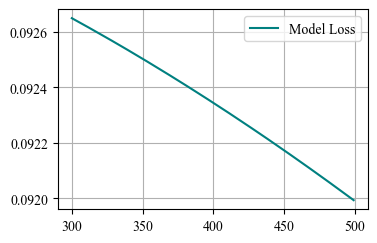



At 1000 th learning epoch,
Model Loss = 0.08956028521060944
Min eigenvalue of P: 1.04037610526575e-06
H(t0+tp): 0.0031801650766283274
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


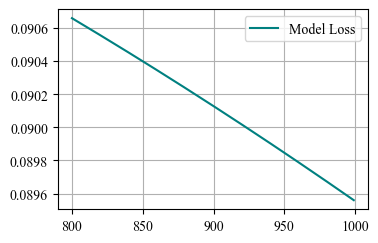



At 1500 th learning epoch,
Model Loss = 0.0860554501414299
Min eigenvalue of P: 1.007194782687293e-06
H(t0+tp): 0.0030571389943361282
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


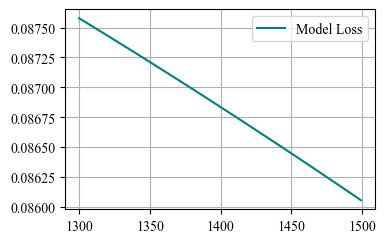



At 2000 th learning epoch,
Model Loss = 0.0814657062292099
Min eigenvalue of P: 9.954000006473507e-07
H(t0+tp): 0.0028960290364921093
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


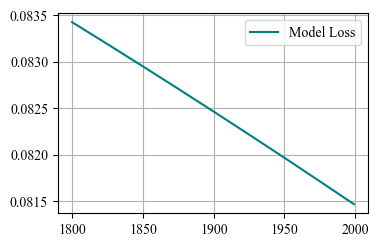



At 2500 th learning epoch,
Model Loss = 0.07576298713684082
Min eigenvalue of P: 1.0129290330951335e-06
H(t0+tp): 0.0026958484668284655
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


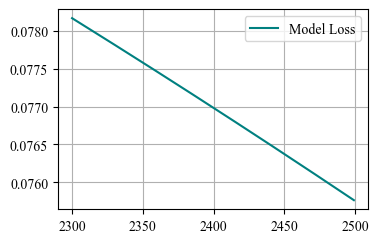



At 3000 th learning epoch,
Model Loss = 0.0696304440498352
Min eigenvalue of P: 1.0187166026298655e-06
H(t0+tp): 0.0024805490393191576
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


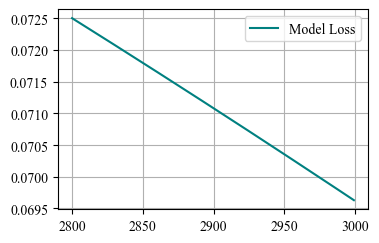



At 3500 th learning epoch,
Model Loss = 0.06170446053147316
Min eigenvalue of P: 1.0111228903042502e-06
H(t0+tp): 0.0022023171186447144
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


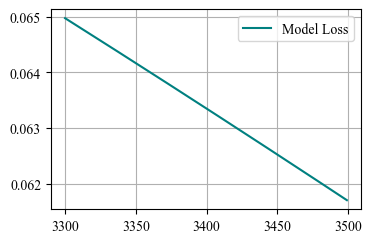



At 4000 th learning epoch,
Model Loss = 0.052937086671590805
Min eigenvalue of P: 1.0258575002808357e-06
H(t0+tp): 0.0018945393385365605
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


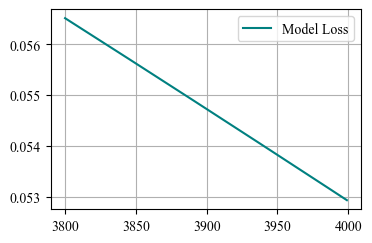



At 4500 th learning epoch,
Model Loss = 0.043660156428813934
Min eigenvalue of P: 9.72368411567004e-07
H(t0+tp): 0.0015688583953306079
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


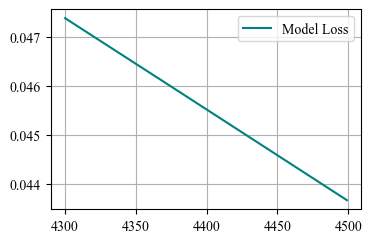



At 5000 th learning epoch,
Model Loss = 0.03782065957784653
Min eigenvalue of P: 9.787736416910775e-07
H(t0+tp): 0.0013637433294206858
loss1 (q1>0): 0.0
loss2 (R≥0): 0.0


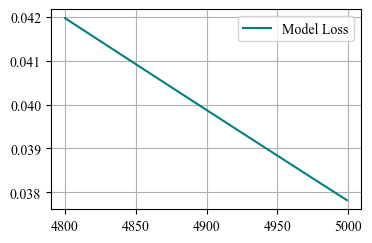

In [33]:
# num_steps = round((tp-t0)/h)
# torch.autograd.set_detect_anomaly(True)
losses = []

model_loss = 1000
n_iter = 0 # number of learning iterations
max_iter = 5000
H_epsilon = 1e-3

zero_tensor = torch.tensor(0, dtype=torch.float)

while model_loss > 0 and n_iter <= max_iter: 
    H_list = []; U_list = []; R_list = []; X_norm_list = [] # ||x(t)||
    t_list = []; q1_list = []
    
    # loss will not be calculated for t0 (the 0th time point)
    running_loss = zero_tensor
    
    loss1_sum = zero_tensor; loss2_sum = zero_tensor; loss3_sum = zero_tensor
    
    for t in np.arange(t0, tf+h, h):
        t_list.append(t)
        pdi_key = 1
    
        # p_bar = [p1_hat^T, p2_hat^T, p3_hat^T, P4_hat^T]^T
        # p_bar = [p1_hat_x, p1_hat_y, p2_hat_x, p2_hat_y, p3_hat_x, p3_hat_y, p4_hat_x, p4_hat_y]^T
        p_bar = []; v_bar = []
    
        for pv_line in input_pv:
            pdi_value = pdi[pdi_key]
    
            pv_sol = f_abm_solver(f_leader_follower, np.array(pv_line), pdi_value, q, t0, h, num_steps, round((t-t0)/h), pdi_key)
            
            if pdi_key == 1:
                csi_hat_norm = 0
                if n_iter == 0:
                    P['p0x'].append(pv_sol[0]); V['v0x'].append(pv_sol[1]); P['p1x'].append(pv_sol[2]); V['v1x'].append(pv_sol[3])
                p1_hat_x = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[1]); v1_hat_x = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p1_hat_x**2 + v1_hat_x**2

            elif pdi_key == 2:
                if n_iter == 0:
                    P['p0y'].append(pv_sol[0]); V['v0y'].append(pv_sol[1]); P['p1y'].append(pv_sol[2]); V['v1y'].append(pv_sol[3])
                p1_hat_y = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[2]); v1_hat_y = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p1_hat_y**2 + v1_hat_y**2

            elif pdi_key == 3:
                if n_iter == 0:
                    P['p2x'].append(pv_sol[2]); V['v2x'].append(pv_sol[3])
                p2_hat_x = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[3]); v2_hat_x = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p2_hat_x**2 + v2_hat_x**2

            elif pdi_key == 4:
                if n_iter == 0:
                    P['p2y'].append(pv_sol[2]); V['v2y'].append(pv_sol[3])
                p2_hat_y = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[4]); v2_hat_y = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p2_hat_y**2 + v2_hat_y**2

            elif pdi_key == 5:
                if n_iter == 0:
                    P['p3x'].append(pv_sol[2]); V['v3x'].append(pv_sol[3])
                p3_hat_x = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[5]); v3_hat_x = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p3_hat_x**2 + v3_hat_x**2

            elif pdi_key == 6:
                if n_iter == 0:
                    P['p3y'].append(pv_sol[2]); V['v3y'].append(pv_sol[3])
                p3_hat_y = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[6]); v3_hat_y = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p3_hat_y**2 + v3_hat_y**2

            elif pdi_key == 7:
                if n_iter == 0:
                    P['p4x'].append(pv_sol[2]); V['v4x'].append(pv_sol[3])
                p4_hat_x = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[7]); v4_hat_x = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p4_hat_x**2 + v4_hat_x**2

            elif pdi_key == 8:
                if n_iter == 0:
                    P['p4y'].append(pv_sol[2]); V['v4y'].append(pv_sol[3])
                p4_hat_y = p_hat_calculator(pv_sol[2], pv_sol[0], pdi[8]); v4_hat_y = v_hat_calculator(pv_sol[3], pv_sol[1])
                csi_hat_norm = csi_hat_norm + p4_hat_y**2 + v4_hat_y**2

            pdi_key = pdi_key + 1
    
        # should go to zero as time processes,
        # meaning that the leader-follower system will maintain their pre-specified realtive positions and velocities
        X_norm_list.append(np.sqrt(csi_hat_norm))
        
        p_bar = [p1_hat_x, p1_hat_y, p2_hat_x, p2_hat_y, p3_hat_x, p3_hat_y, p4_hat_x, p4_hat_y] # .T
        v_bar = [v1_hat_x, v1_hat_y, v2_hat_x, v2_hat_y, v3_hat_x, v3_hat_y, v4_hat_x, v4_hat_y] # .T
    
        # [p_bar^T, v_bar^T]^T
        X_bar = np.transpose(np.hstack((np.array(p_bar), np.array(v_bar)))).reshape(16,1)   # shape = (16,1)
        X_bar_T = np.transpose(X_bar).reshape(1,16)   # shape = (1,16)
    
        # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ Neural
        # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ Network
        
        H_t, P_t = PTs_model(X_bar_T)
        H_list.append(H_t) # ------------------------------------------- H(~all t)

        phi_val = phi_calculator(k3, t0, tp, t)
        dot_phi_val = dot_phi_calculator(k3, t0, tp, t)
        
        
        if round(t,5)<=round(t0+tp,5):
            U_t = (phi_val**(-k3))*H_t  
            U_list.append(U_t) # ------------------- U(~tp)
            

        # running losses 1, 2 are not calculated until the lists contain 2 or more elements
        if round(t,5)>=round(t0+h,5):
            # q1 positive definite (for all t) ============================================================
            Bar_A = torch.tensor(A_bar, dtype=torch.float)
            Bar_C = torch.tensor(C_bar, dtype=torch.float)
            Bar_A_T = torch.tensor(np.transpose(A_bar), dtype=torch.float)
            Bar_C_T = torch.tensor(np.transpose(C_bar), dtype=torch.float)
            
            PAC = torch.matmul(P_t, (Bar_A+Bar_C)) + torch.matmul((Bar_A_T+Bar_C_T), P_t) + 2*kappa*P_t

            eigvals_PAC = torch.linalg.eigvals(-PAC).real
            max_eig_PAC = torch.max(eigvals_PAC)
            
            eigvals_P_inv = torch.linalg.eigvals(torch.linalg.inv(P_t)).real
            max_eig_P_inv = torch.max(eigvals_P_inv)
            
            q1 = max_eig_PAC * max_eig_P_inv
            q1_list.append(q1)

            loss1 = torch.max(zero_tensor, -q1) # q1 > 0
            loss1_sum = loss1_sum + loss1

            # R(t) ≥ 0 (for t ∈ [t0, t0+tp)) ====================================================================
            # not calculated until U_list = [U(t0), U(t0+h), # U(t0+2h), # U(t0+3h),...]
            if round(t,5)>=round(t0+h,5) and round(t,5)<round(t0+tp,5):
                # cD_U = Caputo_frac_derivative_calculator(t, h, U_list, q)
                # phi_X_bar_kron_T = torch.tensor((phi_val**(-k3)), dtype=torch.float)*X_bar_kron_T
                # varphi_phiH = torch.matmul(torch.matmul(torch.matmul(varphi,phi_X_bar_kron_T),M1_t),X_bar_kron)
            
                cD_U = Caputo_frac_derivative_calculator(t, t0, h, U_list, q)
                cD_H = Caputo_frac_derivative_calculator(t, t0, h, H_list, q)

                phi_k = phi_val**(-k3)
                phi_k_minus1 = phi_val**(-k3-1)

                R_t = (phi_k*cD_H - k3*phi_k_minus1*dot_phi_val*H_t - cD_U)
                R_list.append(R_t)
    
                loss2 = torch.max(zero_tensor, (-R_t)) # R(t) ≥ 0
                
            else:
                loss2 = torch.tensor(0, dtype=torch.float)
                
            loss2_sum = loss2_sum + loss2*1000

            running_loss = running_loss + loss1 + loss2*1000
        
    # all eigenvalues should be greater than 0 (for positive definite square matrix)
    min_eig_P = torch.min(torch.linalg.eigvals(P_t).real)
    
    model_loss = torch.max(zero_tensor, torch.abs(H_t)-H_epsilon) + torch.max(zero_tensor,-min_eig_P) + running_loss/((tf-t0)/h)

    if model_loss.item()<=0.0:
        print('============================== SIMULATION DONE ==============================')
        np.savetxt('/Users/ekeulseuji/Downloads/FINAL_P.txt', P_t.detach().numpy(), fmt='%.4f', delimiter=' ')
        print('At Iteration', n_iter)
        print('Final min_eig_P = ', min_eig_P)
        print('\n')
        break;

    elif model_loss.item()>0.0:
        optimizer.zero_grad()
        # backward propagation
        model_loss.backward()
    
        optimizer.step()
    
        # check: P_mat is positive definite or not for t∈[t0,tf)
    
        # save and print the loss
        losses.append(model_loss.item())
    
    n_iter = n_iter + 1

    if n_iter%500==0 or model_loss.item()<= 0.0:
        print('At', n_iter, 'th learning epoch,')
        print('Model Loss =', model_loss.item())
        print('Min eigenvalue of P:', min_eig_P.item())
        
        print('H(t0+tp):', H_list[int(round(tp-t0,5)/h)].item())
        # print('Caputo fractional dreivative of H:', round(cD_H.item(),4))

        print('loss1 (q1>0):', loss1_sum.item()/((tf-t0)/h))
        print('loss2 (R≥0):', loss2_sum.item()/((tp-t0)/h))
        
        plt.figure(figsize=(4,2.6))
        '''
        R_nlist = [r_val.item() for r_val in R_list]
        H_nlist = [h_val.item() for h_val in H_list]

        plt.plot(t_list[1:int((tp-t0)/h)], R_nlist[:], label='R(t)', color='peru')
        plt.plot(t_list[:int((tp-t0)/h)+1], H_nlist[:int((tp-t0)/h)+1], label='H(t)', color='blue')
        # plt.plot(t_list[1:int(tp/h)-1], R_nlist[:-1], label='R(t)', color='darkcyan')
    
        U_nlist = [U_val.item() for U_val in U_list]
        plt.plot(t_list[:int(len(U_list))], U_nlist, label='U(t)', color='blueviolet')

        tp_y = [i for i in np.arange(-50, 250, 0.5)]
        tp_x = [tp]*len(tp_y)
        plt.plot(tp_x, tp_y, label='t_p', color='mediumorchid', dashes=[3,1.5])

        plt.title('H, R, and U Values Over Time', fontname='Times New Roman', fontsize=14)
        plt.xlabel('Time t')
        plt.ylabel('Function Value')

        plt.grid()
        plt.legend()
        '''
        indices = [i for i in range(len(losses))]
        plt.plot(indices[-200:], losses[-200:], label='Model Loss', color='teal')
        plt.grid()
        plt.legend()

        plt.show()

        print('\n')

In [34]:
H_list[int((tp-t0)/h)] # should be <= epsilon

tensor(0.001363, grad_fn=<MulBackward0>)

In [35]:
model_loss

tensor(0.037800, grad_fn=<AddBackward0>)

In [36]:
running_loss

tensor(0., grad_fn=<AddBackward0>)

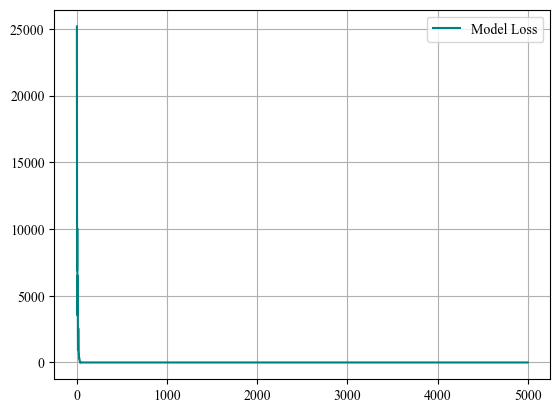

In [37]:
indices = [i for i in range(len(losses))]
plt.plot(indices, losses, label='Model Loss', color='teal')
plt.grid()
plt.legend()

In [38]:
'''
all_t_list = t_list[1:]
tp_list = [i for i in np.arange(t0+h, tp, h)]
vH_nlist = [(1/100000)*vh_val.item() for vh_val in varphiH_list]
WH_nlist = [(1/10)*wh_val.item() for wh_val in cD_pH_minus_InegW_list]

plt.plot(all_t_list, vH_nlist, label='φH(t)', color='blue')
plt.plot(tp_list, WH_nlist, label='I(-W)-D(ɸ^(-k3)H)', color='firebrick')

tp_y = [i for i in np.arange(-2, 7000, 0.5)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label='t_p', color='mediumorchid', dashes=[3,1.5])

plt.title('Function Values Over Time', fontname='Times New Roman', fontsize=14)
plt.xlabel('Time t')
plt.ylabel('Function Values', fontname='Times New Roman')

plt.legend()
plt.grid()
plt.savefig('/Users/ekeulseuji/Downloads/PTS_hw.pdf')
plt.show()
'''

"\nall_t_list = t_list[1:]\ntp_list = [i for i in np.arange(t0+h, tp, h)]\nvH_nlist = [(1/100000)*vh_val.item() for vh_val in varphiH_list]\nWH_nlist = [(1/10)*wh_val.item() for wh_val in cD_pH_minus_InegW_list]\n\nplt.plot(all_t_list, vH_nlist, label='φH(t)', color='blue')\nplt.plot(tp_list, WH_nlist, label='I(-W)-D(ɸ^(-k3)H)', color='firebrick')\n\ntp_y = [i for i in np.arange(-2, 7000, 0.5)]\ntp_x = [tp]*len(tp_y)\nplt.plot(tp_x, tp_y, label='t_p', color='mediumorchid', dashes=[3,1.5])\n\nplt.title('Function Values Over Time', fontname='Times New Roman', fontsize=14)\nplt.xlabel('Time t')\nplt.ylabel('Function Values', fontname='Times New Roman')\n\nplt.legend()\nplt.grid()\nplt.savefig('/Users/ekeulseuji/Downloads/PTS_hw.pdf')\nplt.show()\n"

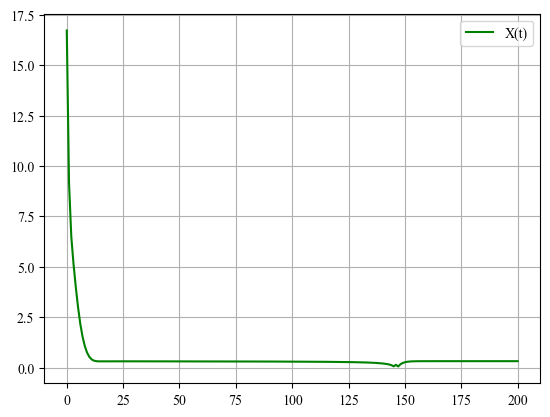

In [39]:
X_indices = [i for i in range(len(X_norm_list))]
X_nlist = [x_val.item() for x_val in X_norm_list]
plt.plot(X_indices, X_nlist, label='X(t)', color='green')
plt.legend()
plt.grid()

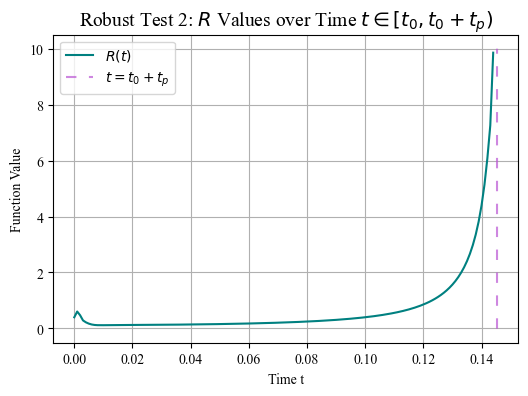

In [42]:
plt.figure(figsize=(6,4))

R_nlist = [r_val.item() for r_val in R_list]

plt.plot(t_list[:int((tp-t0)/h)], R_nlist, label='$R(t)$', color='teal')
# plt.plot(t_list[1:int(tp/h)-1], R_nlist[:-1], label='R(t)', color='darkcyan')

tp_y = [i for i in np.arange(-1e-2, 10, 0.00001)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label=r'$t = t_0 + t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.title(r'Robust Test 2: $R$ Values over Time $t \in [t_0, t_{0}+t_p)$', fontname='Times New Roman', fontsize=14)
plt.xlabel('Time t')
plt.ylabel('Function Value', fontname='Times New Roman')

plt.grid()
plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/RT2_R_val.pdf', dpi=300, bbox_inches='tight')
plt.show()

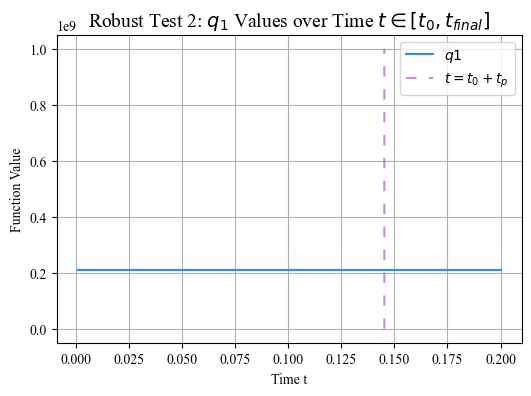

In [44]:
plt.figure(figsize=(6,4))

q_nlist = [q_val.detach().numpy() for q_val in q1_list]

plt.plot(t_list[1:], q_nlist, label='$q1$', color='dodgerblue')
# plt.plot(t_list[1:int(tp/h)-1], R_nlist[:-1], label='R(t)', color='darkcyan')

tp_y = [i for i in np.arange(-100, 1000000000, 100)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label=r'$t = t_0 + t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.title(r'Robust Test 2: $q_1$ Values over Time $t \in [t_0, t_{final}]$', fontname='Times New Roman', fontsize=14)
plt.xlabel('Time t')
plt.ylabel('Function Value', fontname='Times New Roman')

plt.grid()
plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/RT2_q1_val.pdf', dpi=300, bbox_inches='tight')
plt.show()

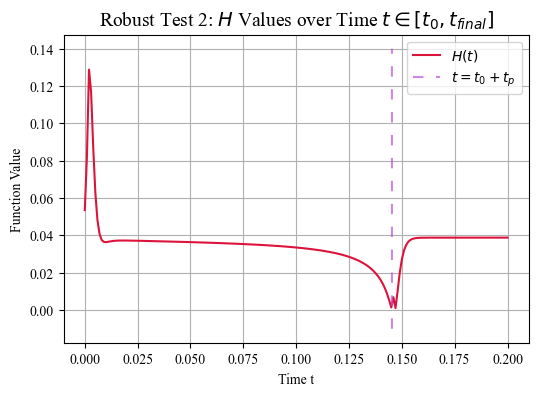

In [49]:
plt.figure(figsize=(6,4))

H_nlist = [h_val.item() for h_val in H_list]

plt.plot(t_list, H_nlist, label='$H(t)$', color='crimson')
# plt.plot(t_list[1:int(tp/h)-1], R_nlist[:-1], label='R(t)', color='darkcyan')

tp_y = [i for i in np.arange(-0.01, 0.14, 0.00001)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label=r'$t = t_0 + t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.title(r'Robust Test 2: $H$ Values over Time $t \in [t_0, t_{final}]$', fontname='Times New Roman', fontsize=14)
plt.xlabel('Time t')
plt.ylabel('Function Value', fontname='Times New Roman')

plt.grid()
plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/RT2_H_val.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
R_nlist[-1]

9.858829498291016

In [51]:
min_eig_P

tensor(1.016393e-06, grad_fn=<MinBackward1>)

### **3D Plot of the Controlled System**

In [52]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [53]:
plot_n = round((t-t0)/h)
t_plot = t_list

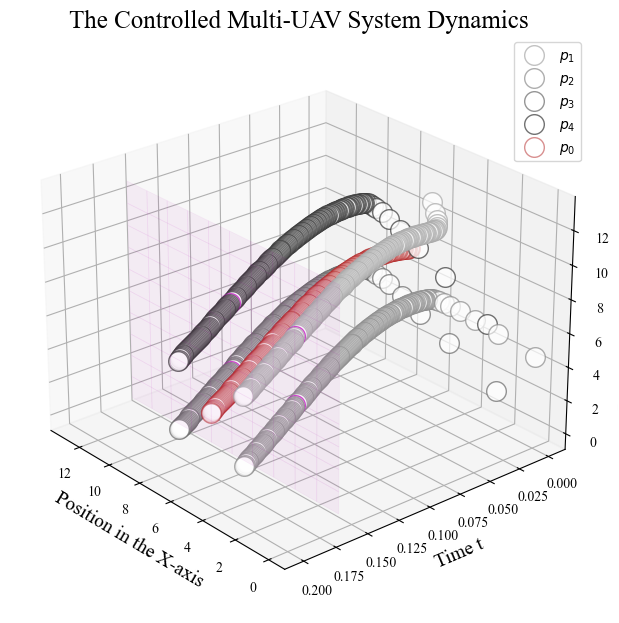

In [56]:
p0_plot = []
p1_plot = []
p2_plot = []
p3_plot = []
p4_plot = []

plt.rcParams['font.family'] = 'Times New Roman'

# plot the starting n points?
for i in range(plot_n):
    p0_plot.append([t_plot[i], P['p0x'][1:][i], P['p0y'][1:][i]])
    p1_plot.append([t_plot[i], P['p1x'][1:][i], P['p1y'][1:][i]])
    p2_plot.append([t_plot[i], P['p2x'][1:][i], P['p2y'][1:][i]])
    p3_plot.append([t_plot[i], P['p3x'][1:][i], P['p3y'][1:][i]])
    p4_plot.append([t_plot[i], P['p4x'][1:][i], P['p4y'][1:][i]])

fig = plt.figure(figsize=(10,7.5))
ax = fig.add_subplot(111, projection='3d')


for elem in p0_plot[:round((tp-t0)/h)-2]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='firebrick', linewidths=1, alpha=0.5)

for elem in p1_plot[:round((tp-t0)/h)-2]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#A8A8A8', linewidths=1, alpha=0.7)

for elem in p2_plot[:round((tp-t0)/h)-2]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#8C8C8C', linewidths=1, alpha=0.7)

for elem in p3_plot[:round((tp-t0)/h)-2]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#696969', linewidths=1, alpha=0.7)

for elem in p4_plot[:round((tp-t0)/h)-2]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#363636', linewidths=1, alpha=0.7)

    
x_grid = np.linspace(0, 13, 11)
z_grid = np.linspace(0, 13, 11)
xa, za = np.meshgrid(x_grid, z_grid)

ta = np.full_like(xa, tp+0.015) 

ax.plot_surface(xa, ta, za, color='m', alpha=0.05, edgecolor='m', linewidth=0.5)


for elem in p0_plot[round((tp-t0)/h)-1:round((tp-t0)/h)]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='firebrick', linewidths=1, alpha=0.5)

for elem in p1_plot[round((tp-t0)/h)-1:round((tp-t0)/h)]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='m', linewidths=1, alpha=0.7)

for elem in p2_plot[round((tp-t0)/h)-1:round((tp-t0)/h)]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='m', linewidths=1, alpha=0.7)

for elem in p3_plot[round((tp-t0)/h)-1:round((tp-t0)/h)]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='m', linewidths=1, alpha=0.7)

for elem in p4_plot[round((tp-t0)/h)-1:round((tp-t0)/h)]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='m', linewidths=1, alpha=0.7)

    
for elem in p0_plot[round((tp-t0)/h):]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='firebrick', linewidths=1, alpha=0.5)

for elem in p1_plot[round((tp-t0)/h):]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#A8A8A8', linewidths=1, alpha=0.7)

for elem in p2_plot[round((tp-t0)/h):]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#8C8C8C', linewidths=1, alpha=0.7)

for elem in p3_plot[round((tp-t0)/h):]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#696969', linewidths=1, alpha=0.7)

for elem in p4_plot[round((tp-t0)/h):]:
    ax.scatter(elem[1], elem[0], elem[2], s=200, c=elem[1], cmap='Greys', edgecolor='#363636', linewidths=1, alpha=0.7)

    


ax.scatter(P['p1x'][-1], t_plot[-1], P['p1y'][-1], s=200, c=P['p1x'][-1], cmap='Greys', edgecolor='#A8A8A8', linewidths=1, label='$p_1$', alpha=0.7)
# ax.annotate('p1', (P['p1x'][plot_n], P['p1y'][plot_n]))  

ax.scatter(P['p2x'][-1], t_plot[-1], P['p2y'][-1], s=200, c=P['p2x'][-1], cmap='Greys', edgecolor='#8C8C8C', linewidths=1, label='$p_2$', alpha=0.7)
# ax.annotate('p2', (P['p2x'][0], P['p2y'][0]))  

ax.scatter(P['p3x'][-1], t_plot[-1], P['p3y'][-1], s=200, c=P['p3x'][-1], cmap='Greys', edgecolor='#696969', linewidths=1, label='$p_3$', alpha=0.7)
# ax.annotate('p3', (P['p3x'][0], P['p3y'][0]))  

ax.scatter(P['p4x'][-1], t_plot[-1], P['p4y'][-1], s=200, c=P['p4x'][-1], cmap='Greys',  edgecolor='#363636', linewidths=1, label='$p_4$', alpha=0.7)
# ax.annotate('p4', (P['p4x'][0], P['p4y'][0]))  

ax.scatter(P['p0x'][-1], t_plot[-1], P['p0y'][-1], s=200, c=P['p0x'][-1], cmap='Greys', edgecolor='firebrick', linewidths=1, label='$p_0$', alpha=0.5)
# ax.annotate('p0', (P['p0x'][plot_n], P['p0y'][plot_n]))  




ax.set_xlabel('Position in the X-axis', fontname='Times New Roman', fontsize=14)
ax.set_ylabel('Time t', fontname='Times New Roman', fontsize=14)
ax.set_zlabel('Position in the Y-axis', fontname='Times New Roman', fontsize=14)

ax.set_title('The Controlled Multi-UAV System Dynamics', fontname='Times New Roman', fontsize=18)
ax.view_init(elev=25.5, azim=-220.5)

plt.grid()
plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/RT2_revPTS_3dDyn.pdf')
plt.show()

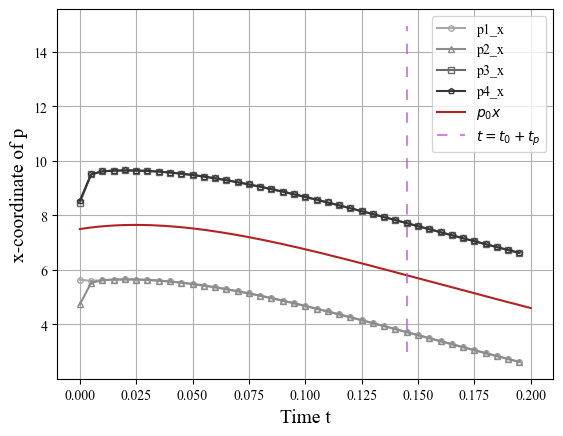

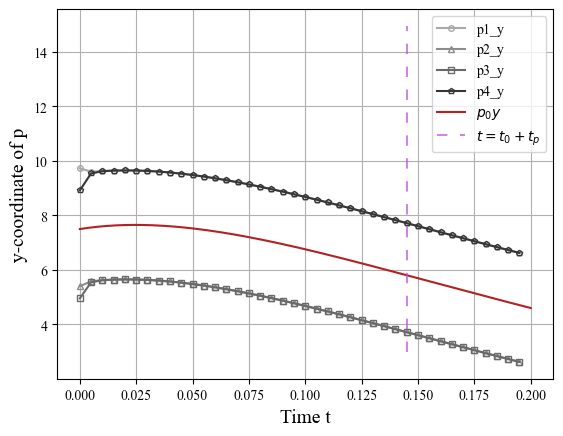

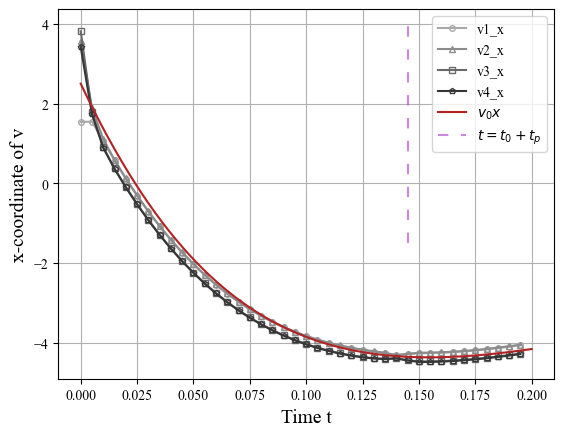

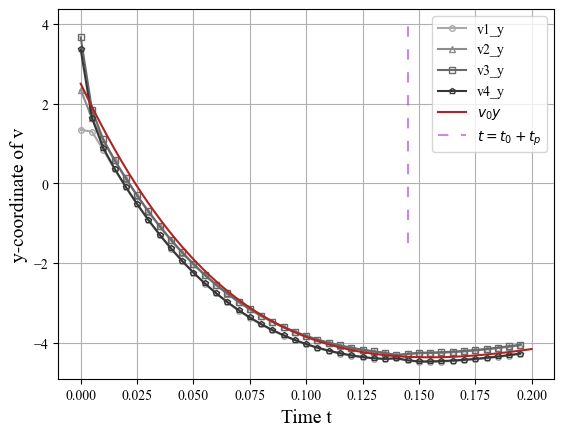

In [55]:
colors = ['#A8A8A8', '#8C8C8C', '#696969', '#363636'] 
markers = ['o', '^', 's', 'p']

for i, plot_list in enumerate([P['p1x'][::5], P['p2x'][::5], P['p3x'][::5], P['p4x'][::5]]):
    plt.plot(t_plot[:-1][::5], plot_list[1:], label=f'p{i+1}_x', color=colors[i], marker=markers[i], markerfacecolor='none', markersize=4)
    # plt.title('X-axis Position for the Agents from t0 to tp', fontname='Times New Roman', fontsize=16)
    plt.xlabel('Time t', fontname='Times New Roman', fontsize=14)
    plt.ylabel('x-coordinate of p', fontname='Times New Roman', fontsize=14)
    plt.legend()
    plt.grid(True)

plt.plot(t_plot, P['p0x'][1:], label='$p_{0}x$', color='firebrick')

tp_y = [i for i in np.arange(3, 15, 0.05)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label='$t = t_0+t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/revPTS_px.pdf')
plt.show()

for i, plot_list in enumerate([P['p1y'][::5], P['p2y'][::5], P['p3y'][::5], P['p4y'][::5]]):
    plt.plot(t_plot[:-1][::5], plot_list[1:], label=f'p{i+1}_y', color=colors[i], marker=markers[i], markerfacecolor='none', markersize=4)
    # plt.title('Y-axis Position for the Agents from t0 to tp', fontname='Times New Roman', fontsize=16)
    plt.xlabel('Time t', fontname='Times New Roman', fontsize=14)
    plt.ylabel('y-coordinate of p', fontname='Times New Roman', fontsize=14)
    plt.legend()
    plt.grid(True)
    

plt.plot(t_plot, P['p0y'][1:], label='$p_{0}y$', color='firebrick')

tp_y = [i for i in np.arange(3, 15, 0.05)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label='$t = t_0+t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/revPTS_py.pdf')
plt.show()


for i, plot_list in enumerate([V['v1x'][::5], V['v2x'][::5], V['v3x'][::5], V['v4x'][::5]]):
    plt.plot(t_plot[:-1][::5], plot_list[1:], label=f'v{i+1}_x', color=colors[i], marker=markers[i], markerfacecolor='none', markersize=4)
    plt.xlabel('Time t', fontname='Times New Roman', fontsize=14)
    plt.ylabel('x-coordinate of v', fontname='Times New Roman', fontsize=14)
    plt.legend()
    plt.grid(True)

plt.plot(t_plot, V['v0x'][1:], label='$v_{0}x$', color='firebrick')    

tp_y = [i for i in np.arange(-1.5, 4, 0.05)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label='$t = t_0+t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/revPTS_vx.pdf')
plt.show()

for i, plot_list in enumerate([V['v1y'][::5], V['v2y'][::5], V['v3y'][::5], V['v4y'][::5]]):
    plt.plot(t_plot[:-1][::5], plot_list[1:], label=f'v{i+1}_y', color=colors[i], marker=markers[i], markerfacecolor='none', markersize=4)
    plt.xlabel('Time t', fontname='Times New Roman', fontsize=14)
    plt.ylabel('y-coordinate of v', fontname='Times New Roman', fontsize=14)
    plt.legend()
    plt.grid(True)
    
plt.plot(t_plot, V['v0y'][1:], label='$v_{0}y$', color='firebrick')    

tp_y = [i for i in np.arange(-1.5, 4, 0.05)]
tp_x = [tp]*len(tp_y)
plt.plot(tp_x, tp_y, label='$t = t_0+t_p$', color='mediumorchid', dashes=[5,6], alpha=0.7)

plt.legend()
plt.savefig('/Users/ekeulseuji/Downloads/revPTS_vy.pdf')
plt.show()

In [ ]:
np.savetxt('/Users/ekeulseuji/Downloads/FINAL_P.txt', P_t.detach().numpy(), fmt='%.4f', delimiter=' ')

In [ ]:
P['p0x'][int(tp/h)]

In [ ]:
P['p0y'][int(tp/h)]

In [ ]:
V['v0x'][int(tp/h)]

In [ ]:
V['v0y'][int(tp/h)]

In [ ]:
P['p1x'][int(tp/h)]

In [ ]:
P['p1y'][int(tp/h)]

In [ ]:
P['p2x'][int(tp/h)]

In [ ]:
P['p2y'][int(tp/h)]

In [ ]:
P['p3x'][int(tp/h)]

In [ ]:
P['p3y'][int(tp/h)]

In [ ]:
P['p4x'][int(tp/h)]

In [ ]:
P['p4y'][int(tp/h)]

In [ ]:
V['v0x'][int(tp/h)]

In [ ]:
V['v0y'][int(tp/h)]

In [ ]:
V['v1x'][int(tp/h)]

In [ ]:
V['v1y'][int(tp/h)]

In [ ]:
V['v2x'][int(tp/h)]

In [ ]:
V['v2y'][int(tp/h)]

In [ ]:
V['v3x'][int(tp/h)]

In [ ]:
V['v3y'][int(tp/h)]

In [ ]:
V['v4x'][int(tp/h)]

In [ ]:
V['v4y'][int(tp/h)]

## just to make nicer pics ☆ ☆ ☆ ☆ ☆ 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams['font.family'] = 'Times New Roman'
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
colors = ['#A8A8A8', '#8C8C8C', '#696969', '#363636']
markers = ['o', '^', 's', 'p']

for i, plot_list in enumerate([P['p1x'][::5], P['p2x'][::5], P['p3x'][::5], P['p4x'][::5]]):
    ax1.plot(t_plot[:-1][::5], plot_list[1:], 
             label=f'$p_{i+1}x$', color=colors[i], 
             marker=markers[i], markerfacecolor='none', markersize=4)

ax1.plot(t_plot, P['p0x'][1:], label='$p_{0}x$', color='firebrick')

tp_y_range = np.arange(3, 15, 0.05)
ax1.plot([tp]*len(tp_y_range), tp_y_range, 
         label='$t=t_0+t_p$', color='mediumorchid', linestyle='--', alpha=0.7)
ax1.set_xlabel('Time t', fontsize=12)
ax1.set_ylabel('x-coordinate of p', fontsize=12)
ax1.set_title(r"Evolution of Agents' X-axis Positions over Time $t \in [t_0, t_{final}]$", fontsize=14)
ax1.legend(loc='best', fontsize=8)
ax1.grid(True)


ax2 = axes[0, 1]
for i, plot_list in enumerate([P['p1y'][::5], P['p2y'][::5], P['p3y'][::5], P['p4y'][::5]]):
    ax2.plot(t_plot[:-1][::5], plot_list[1:], 
             label=f'$p_{i+1}y$', color=colors[i], 
             marker=markers[i], markerfacecolor='none', markersize=4)
ax2.plot(t_plot, P['p0y'][1:], label='$p_{0}y$', color='firebrick')
tp_y_range = np.arange(3, 15, 0.05)
ax2.plot([tp]*len(tp_y_range), tp_y_range, 
         label='$t=t_0+t_p$', color='mediumorchid', linestyle='--', alpha=0.7)
ax2.set_xlabel('Time t', fontsize=12)
ax2.set_ylabel('y-coordinate of p', fontsize=12)
ax2.set_title(r" Evolution of Agents' Y-axis Positions over Time $t \in [t_0, t_{final}]$", fontsize=14)
ax2.legend(loc='best', fontsize=8)
ax2.grid(True)


ax3 = axes[1, 0]
for i, plot_list in enumerate([V['v1x'][::5], V['v2x'][::5], V['v3x'][::5], V['v4x'][::5]]):
    ax3.plot(t_plot[:-1][::5], plot_list[1:], 
             label=f'$v_{i+1}x$', color=colors[i], 
             marker=markers[i], markerfacecolor='none', markersize=4)
ax3.plot(t_plot, V['v0x'][1:], label='$v_{0}x$', color='firebrick')
tp_y_range = np.arange(-1.5, 4, 0.05)
ax3.plot([tp]*len(tp_y_range), tp_y_range, 
         label='$t=t_0+t_p$', color='mediumorchid', linestyle='--', alpha=0.7)
ax3.set_xlabel('Time t', fontsize=12)
ax3.set_ylabel('x-coordinate of v', fontsize=12)
ax3.set_title(r"Evolution of Agents' X-axis Velocities over Time $t \in [t_0, t_{final}]$", fontsize=14)
ax3.legend(loc='best', fontsize=8)
ax3.grid(True)


ax4 = axes[1, 1]
for i, plot_list in enumerate([V['v1y'][::5], V['v2y'][::5], V['v3y'][::5], V['v4y'][::5]]):
    ax4.plot(t_plot[:-1][::5], plot_list[1:], 
             label=f'$v_{i+1}y$', color=colors[i], 
             marker=markers[i], markerfacecolor='none', markersize=4)
ax4.plot(t_plot, V['v0y'][1:], label='$v_{0}y$', color='firebrick')
tp_y_range = np.arange(-1.5, 4.5, 0.05)
ax4.plot([tp]*len(tp_y_range), tp_y_range, 
         label='$t=t_0+t_p$', color='mediumorchid', linestyle='--', alpha=0.7)
ax4.set_xlabel('Time t', fontsize=12)
ax4.set_ylabel('y-coordinate of v', fontsize=12)
ax4.set_title(r"Evolution of Agents' Y-axis Velocities over Time $t \in [t_0, t_{final}]$", fontsize=14)
ax4.legend(loc='best', fontsize=8)
ax4.grid(True)

plt.tight_layout()

plt.savefig('/Users/ekeulseuji/Downloads/revPTS_combined.pdf', dpi=300, bbox_inches='tight')

In [ ]:
1